# HySwash: Surrogate Modeling and Long-Term Reconstruction

In the previous notebook, we used SWASH to simulate a representative set of
offshore wave conditions selected with MDA.

In this notebook, we will use those simulations to train **surrogate models**
that reproduce the nearshore wave transformation at a fraction of the
computational cost.

We will then apply these surrogate models to a long time series of offshore
forcing conditions to reconstruct the corresponding **nearshore wave climate**.

In [1]:
import os
import os.path as op
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import xarray as xr

sys.path.insert(0, "..")

from utils.plotting import (
    plot_depthfile,
)

## Load the SWASH simulations

We will start by loading the HySwash configuration, the MDA model, and the
postprocessed SWASH simulations generated in the previous notebook.

These simulations will provide the **training data** for the surrogate models.

In [2]:
root_dir = os.getcwd()
output_dir = op.join(root_dir, "output")
templates_dir = op.join(root_dir, "templates")
export_dir = op.join(root_dir, "export")

In [3]:
from bluemath_tk.core.io import load_model

mda = load_model(op.join(export_dir, "mda_model.pkl"))
swash_model = load_model(op.join(export_dir, "swash_model.pkl"))

depth_file = op.join(templates_dir, "depth.bot")
depth_array = np.loadtxt(depth_file)

postprocessed_output = xr.open_dataset(
    op.join(output_dir, "output_postprocessed.nc")
)

postprocessed_output

<xarray.Dataset> Size: 625kB
Dimensions:   (case_num: 10, Tsec: 450, Xp: 1200)
Coordinates:
  * case_num  (case_num) int64 80B 0 1 2 3 4 5 6 7 8 9
  * Tsec      (Tsec) int64 4kB 0 1 2 3 4 5 6 7 ... 443 444 445 446 447 448 449
  * Xp        (Xp) int64 10kB 0 1 2 3 4 5 6 ... 1194 1195 1196 1197 1198 1199
    Yp        int64 8B ...
Data variables:
    Ru2       (case_num) float64 80B ...
    Runlev    (case_num, Tsec) float64 36kB ...
    Msetup    (case_num, Xp) float64 96kB ...
    Hrms      (case_num, Xp) float64 96kB ...
    Hs        (case_num, Xp) float64 96kB ...
    Hss       (case_num, Xp) float64 96kB ...
    ig        (case_num, Xp) float64 96kB ...
    Hvlf      (case_num, Xp) float64 96kB ...

## Build the surrogate model

The SWASH simulations provide spatially distributed results along the
cross-shore profile for a limited number of representative offshore conditions.

Our goal is to predict these spatial fields for **new offshore conditions**
without running SWASH again.

HySwash combines two techniques for this purpose:

1. **Principal Component Analysis (PCA)** reduces each spatial SWASH output to a
   small number of principal components.
2. **Radial Basis Functions (RBF)** interpolate the principal components as a
   function of the offshore forcing conditions.

For a new combination of offshore conditions, the RBF model predicts the
principal components, and the PCA transformation is inverted to reconstruct
the complete cross-shore field.

**SWASH simulations → PCA → RBF → predicted PCs → spatial reconstruction**

### Principal Component Analysis (PCA)

The postprocessed SWASH outputs contain one value at each cross-shore location.
Instead of building an independent surrogate model for every location, we use
PCA to represent these spatial fields with a smaller number of variables.

PCA identifies the dominant spatial patterns in the SWASH simulations and
represents each simulation through its corresponding **principal component
scores (PCs)**.

By retaining only the components that explain most of the variance, we reduce
the dimensionality of the problem while preserving the dominant spatial
variability.

In [5]:
var_to_predict = 'Hs'

In [6]:
from bluemath_tk.datamining.pca import PCA

pca = PCA()

pca.fit_transform(
    data=postprocessed_output,
    vars_to_stack=[var_to_predict],
    coords_to_stack=["Xp"],
    pca_dim_for_rows="case_num",
    value_to_replace_nans={var_to_predict: 0.0},
)

pca.save_model(
    model_path=op.join(export_dir, "pca_model.pkl"),
)

2026-09-23 01:58:31,139 - PCA - WARNING - Using 969 out of 1200 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-09-23 01:58:31,238 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!


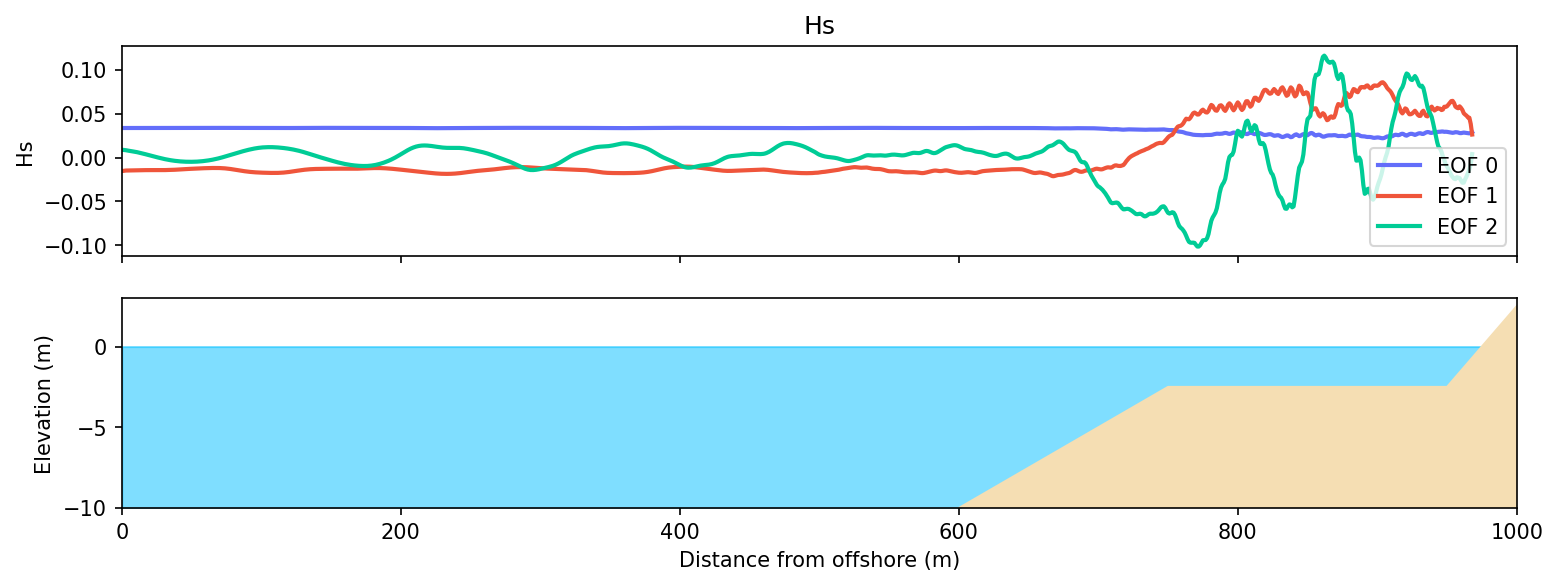

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharex=True, dpi=150)
plot_depthfile(depth_array, ax=axs[1])

for component in pca.eofs.n_component.values:
    values = pca.eofs.isel(n_component=component)[var_to_predict]
    values.plot(
        ax=axs[0],
        color=px.colors.qualitative.Plotly[component],
        lw=2,
        label=f"EOF {component}"
    )

axs[1].set_ylim(-10, 3)
axs[1].set_xlim(0, 1000)
axs[0].set_title(var_to_predict)
axs[0].set_xlabel("")   
axs[0].legend()
plt.show()


### Spatial surrogate: RBF interpolation

Once the spatial fields have been represented by their principal components,
we need to relate those components to the offshore forcing conditions.

For this purpose, HySwash uses **Radial Basis Function (RBF) interpolation**.
The RBF model learns the relationship between:

**offshore forcing conditions → principal component scores**

For new offshore conditions, the RBF predicts the PCs, which can then be
transformed back through the PCA model to reconstruct the complete spatial field.

**offshore conditions → RBF → PCs → inverse PCA → spatial field**

In [8]:
from bluemath_tk.interpolation.rbf import RBF

rbf_spatial = RBF()

rbf_spatial.fit(
    subset_data=mda.centroids.iloc[postprocessed_output["case_num"].values],
    target_data=pca.pcs_df,
)

rbf_spatial.save_model(
    model_path=op.join(export_dir, "rbf_spatial_model.pkl")
)

### Scalar surrogate: wave runup

Some SWASH outputs, such as `Ru2`, contain a **single value for each
simulation**. In this case, dimensionality reduction is not required.

The RBF can therefore be trained directly between the offshore forcing
conditions and the scalar output:

**offshore conditions → RBF → `Ru2`**

This provides a simpler surrogate-modeling strategy for scalar quantities.

In [9]:
Ru2 = pd.DataFrame(
    postprocessed_output["Ru2"].values,
    columns=["Ru2"],
)

rbf_scalar = RBF()

rbf_scalar.fit(
    subset_data=mda.centroids.iloc[postprocessed_output["case_num"].values],
    target_data=Ru2,
)

rbf_scalar.save_model(
    model_path=op.join(export_dir, "rbf_scalar_model.pkl")
)

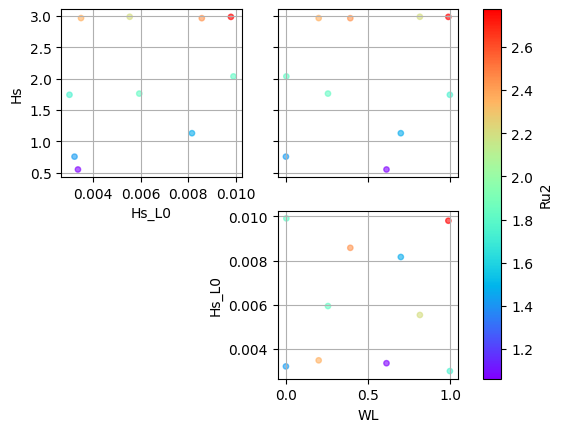

In [11]:
from bluemath_tk.core.plotting.scatter import plot_scatters_in_triangle

df_train = pd.concat([mda.centroids, Ru2], axis=1)

fig, axs = plot_scatters_in_triangle(
    [df_train],
    variables=["Hs", "Hs_L0", "WL"],
    color="Ru2",
    cmap="rainbow",
    s=15,
)

## Reconstruction

Now that both surrogate models have been trained, we can apply them to new
offshore forcing conditions without running additional SWASH simulations.

We will use the **10,000 conditions generated with LHS** to illustrate the two
reconstruction strategies:

- **Scalar reconstruction:** predict `Ru2` directly with the scalar RBF.
- **Spatial reconstruction:** predict the PCs with the spatial RBF and use the
  inverse PCA transformation to recover the complete cross-shore field.

In [12]:
df_predict = pd.read_pickle(
    op.join(export_dir, "lhs_dataset.pkl")
)

### 1. Scalar reconstruction

For scalar outputs, the reconstruction is performed directly by the RBF model.

Here, we predict `Ru2` for all LHS forcing combinations.

In [13]:
df_predict = df_predict.iloc[:50, :3]  # Select only the first three columns (Hs, Hs_L0, WL)
Ru2_reconstructed = rbf_scalar.predict(df_predict)
df_predict["Ru2"] = Ru2_reconstructed

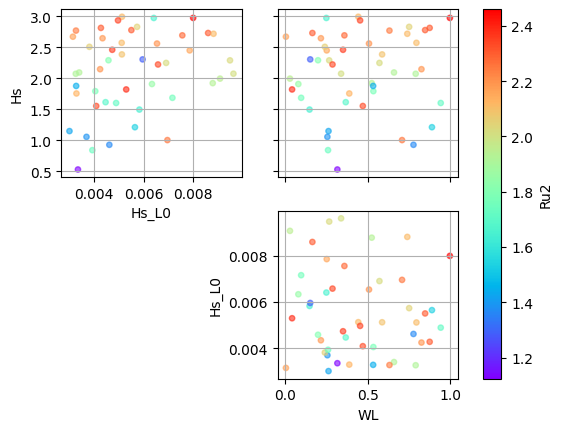

In [14]:
fig, axs = plot_scatters_in_triangle(
    [df_predict],
    variables=["Hs", "Hs_L0", "WL"],
    color="Ru2",
    cmap="rainbow",
    s=15,
)

### 2. Spatial reconstruction

Spatial outputs require an additional step.

First, the RBF model predicts the principal component scores for each new
offshore condition. The PCA transformation is then inverted to recover the
complete spatial field along the cross-shore profile.

**new forcing → predicted PCs → inverse PCA → reconstructed field**

In [17]:
df_predict

,Hs,Hs_L0,WL,Ru2
0,1.599622,0.004896,0.941386,1.717420
1,2.643763,0.004351,0.216158,2.189919
2,1.905543,0.006337,0.079645,1.852800
3,2.091993,0.003412,0.658546,1.920288
4,2.558418,0.006539,0.507270,2.203159
5,2.383137,0.005129,0.586560,2.093589
6,1.919949,0.008778,0.523725,1.928189
7,1.209180,0.005653,0.888202,1.534594
8,1.493760,0.005832,0.147446,1.641913
9,2.690431,0.007556,0.358403,2.280299


In [18]:
pcs_reconstructed = rbf_spatial.predict(df_predict[["Hs", "Hs_L0", "WL"]])


In [19]:
pcs_reconstructed_xr = xr.DataArray(
    pcs_reconstructed.values,
    dims=[pca.pca_dim_for_rows, "PCs"],
    coords={
        pca.pca_dim_for_rows: pcs_reconstructed.index.values,
        "PCs": pcs_reconstructed.columns.values,
    },
)

data_reconstructed = pca.inverse_transform(pcs_reconstructed_xr)


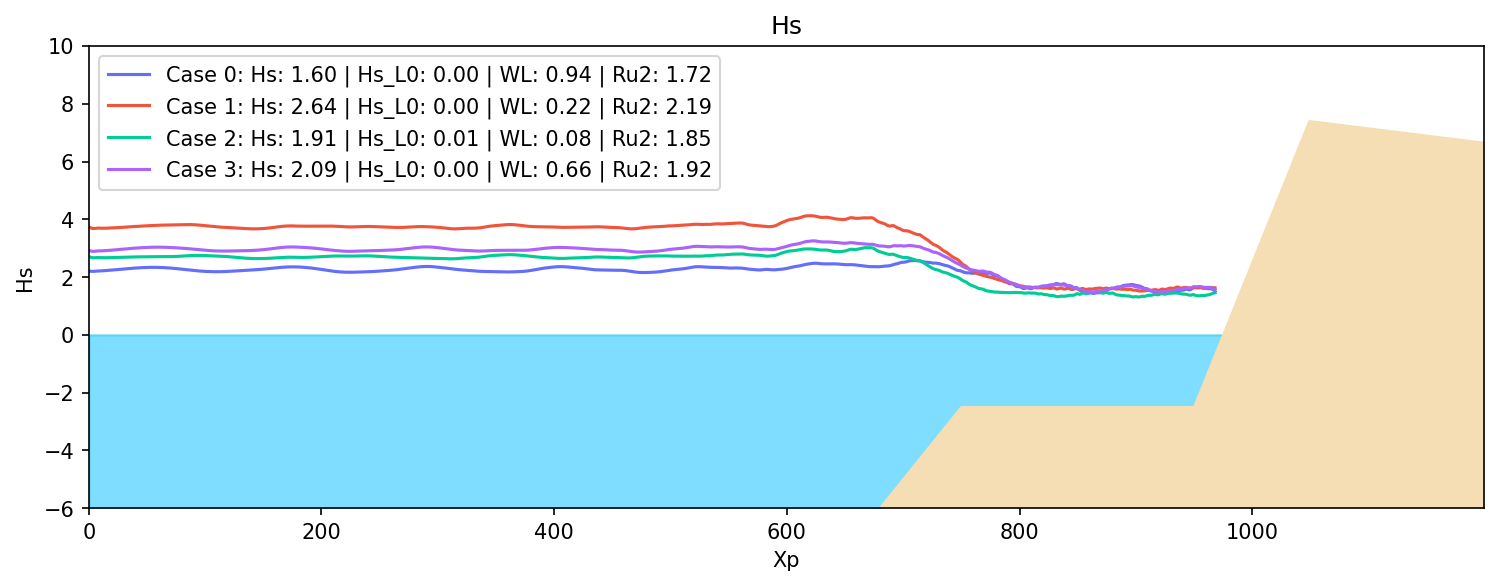

In [22]:
postprocessed_var = "Hs"
cases = [0, 1, 2, 3]

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
plot_depthfile(depth_array, ax=ax)

for case_num in cases:
    values = df_predict.iloc[case_num].to_dict()
    data = data_reconstructed[postprocessed_var].isel(case_num=case_num)

    if postprocessed_var == "Msetup":
        data = data + values["WL"]

    data.plot(
        ax=ax,
        color=px.colors.qualitative.Plotly[case_num],
        label=f"Case {case_num}: "
        + " | ".join(f"{k}: {v:.2f}" for k, v in values.items()),
    )

ax.set_ylim(-6, 10)
ax.set_title(postprocessed_var)
ax.legend()
plt.show()
